In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [1]:
pip install graphviz



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [87]:
def f(x):
  return 3*x**2-4*x+5

In [88]:
f(3.0)

20.0

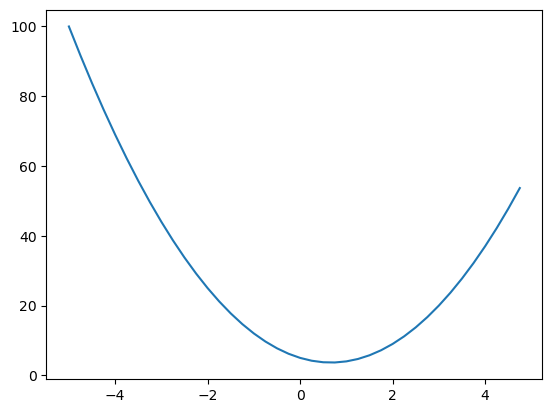

In [89]:
xs=np.arange(-5,5,0.25)
ys=f(xs)

plt.plot(xs, ys)
plt.show()

In [24]:
h=0.00001
x=2/3
(f(x+h)-f(x))/h

3.0000002482211127e-05

In [90]:
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

4.0


In [91]:
h=0.0001
a=2.0
b=-3.0
c=10.0

d1=a*b+c
a+=h
d2=a*b+c
#change a by a+=h
print('change a by a+=h')
print('d1',d1) #4
print('d2',d2) #4+bh=4+(-3)*0.0001
print('slope',(d2-d1)/h) #b=-3
a-=h

d1=a*b+c
b+=h
d2=a*b+c
#change b by b+=h
print('change b by b+=h')
print('d1',d1) #4
print('d2',d2) #4+ah=4+(2)*0.0001=4.0002
print('slope',(d2-d1)/h) #a=2
b-=h


d1=a*b+c
c+=h
d2=a*b+c
#change c by c+=h
print('change c by c+=h')
print('d1',d1) #4
print('d2',d2) #4+h=4+0.0001=4.0001
print('slope',(d2-d1)/h) #1
c-=h

change a by a+=h
d1 4.0
d2 3.999699999999999
slope -3.000000000010772
change b by b+=h
d1 4.0
d2 4.0002
slope 2.0000000000042206
change c by c+=h
d1 4.0
d2 4.0001
slope 0.9999999999976694


In [38]:
class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data=data
    self.grad=0.0
    self._backward=lambda:None
    self._prev=tuple(_children)
    self._op=_op
    self.label=label
#这些都是magic method,__repr__是可以输入a b查看数据多少以及名称，__add__啥的都是重载，是写到python协议里的
  """
  这两点其实涉及到了 Python 对象模型中非常核心的概念：
  魔术方法（Magic Methods）。
  我们可以把它们看作是 Python 预留的“后门”，让你的自定义类能像内置类型（比如整数、列表）一样自然。
  """
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    out=Value(self.data+other.data,(self,other),'+')

    """这是一个闭包（Closure）。它定义了一个函数，但现在不执行。
    它被存在 out._backward 里，像是一个“锦囊妙计”，
    等到以后我们调用 loss.backward() 时，才会按照从后往前的顺序打开这个锦囊。"""
  #实际上就是闭包
  #加法的梯度就是自己，所以乘1.0
    def _backward():
      self.grad += 1.0*out.grad
      other.grad += 1.0*out.grad
    out._backward=_backward
    return out
  

  def __mul__(self,other):
    out=Value(self.data*other.data,(self,other),'*')
  #乘法的梯度有链式法则，需要算输出的梯度等于输入的梯度*当前的梯度
    def _backward():
      self.grad += other.data*out.grad
      other.grad += self.data*out.grad
    out._backward=_backward
    return out
  
  def tanh(self):
    x=self.data
    """
    (e^2*x-1)/(e^2*x+1)
    """
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out=Value(t,(self,),'tanh')
    #输入端的梯度 = 本地梯度 * 输出端的梯度（上游传回来的梯度）。
    def _backward():
      self.grad+=(1-t**2)*out.grad
    out._backward=_backward
    return out
  
  def backward(self):
        #生成的拓扑图
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad=1.0
    for node in reversed(topo):
      node._backward()


a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=d*f;L.label='L'
L

# (a.__mul__(b)).__add__(c)
#a.__add__(b)

Value(data=-8.0)

In [39]:
def trace(root):
  nodes, edges = [], []
  seen = set()

  def build(v):
    if v not in seen:
      seen.add(v)
      nodes.append(v)
      for child in v._prev:
        edges.append((child, v))
        build(child)

  build(root)
  return nodes, edges


def draw_dot(root):
  try:
    from graphviz import Digraph
  except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
      "需要先安装 graphviz：pip install graphviz。"
      "如果还渲染不出来，还需要安装系统 Graphviz 程序。"
    ) from exc

  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    dot.node(
      name=uid,
      label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad),
      shape='record'
    )
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

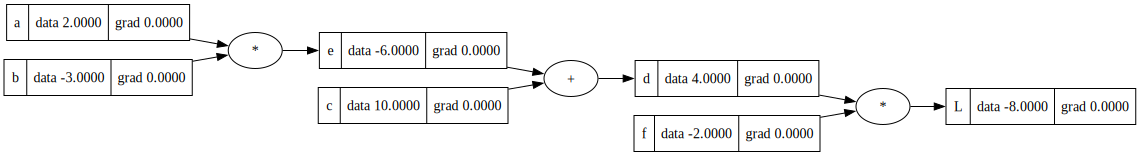

In [40]:
draw_dot(L)

In [41]:
#输出组成d的那俩d=e+c;d.label='d' e和c
d._prev 

(Value(data=-6.0), Value(data=10.0))

In [42]:
d._op

'+'

In [43]:
#要演示一下损失函数，这个前面就是正常的载入数据，后面就是加个增量看看梯度
def lol():
  h=0.0001
  a=Value(2.0,label='a')
  b=Value(-3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  f=Value(-2.0,label='f')
  L=d*f;L.label='L'
  L1=L.data

  a=Value(2.0+h,label='a')
  b=Value(-3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  f=Value(-2.0,label='f')
  L=d*f;L.label='L'
  L2=L.data
  #bf
  print((L2-L1)/h)

lol()

6.000000000021544


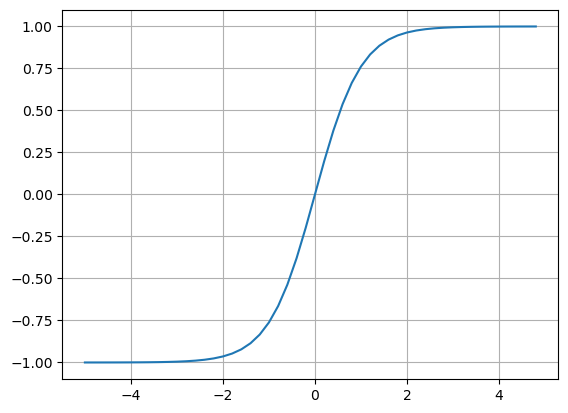

In [44]:
#这个就是演示tanhx()
x=np.arange(-5,5,0.2)
plt.plot(x,np.tanh(x));
plt.grid()
plt.show()

In [50]:
#inputs x1,x2
x1=Value(2.0,label='x1')
x2=Value(3.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.88888,label='b')
#n=0
# x1*w1+x2*w2+b
x1w1=x1*w1;x1w1.label='x1*w1'
x2w2=x2*w2;x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b;n.label='n';
o=n.tanh();o.label='o'

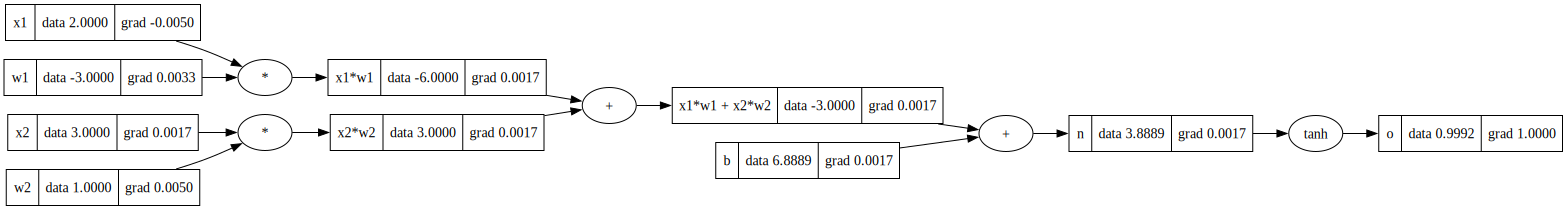

In [53]:
draw_dot(o)

In [ ]:
#相当于自动反向传播了
o.backward()

In [48]:
#生成的拓扑图
topo=[]
visited=set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=3.0),
 Value(data=1.0),
 Value(data=3.0),
 Value(data=-3.0),
 Value(data=6.88888),
 Value(data=3.8888800000000003),
 Value(data=0.9991624517477322)]

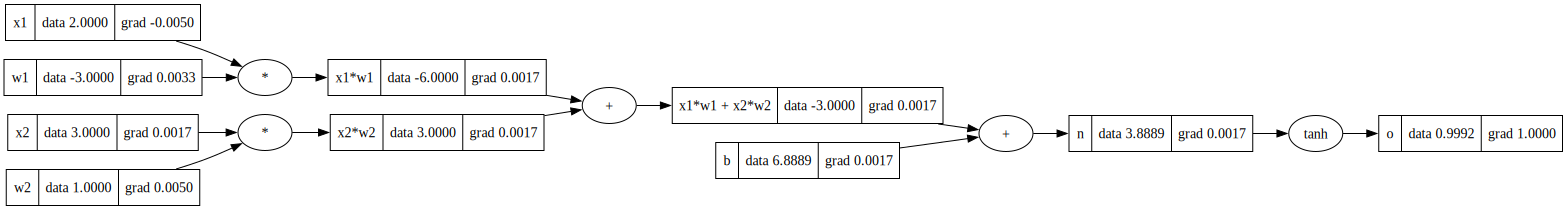

In [ ]:
#实验 1：自动跑完整 backward
# 清空所有梯度
for node in topo:
  node.grad = 0.0

# 从输出开始
o.grad = 1.0

# 反向传播
for node in reversed(topo):
  node._backward()

draw_dot(o)
#能验证这个x1.grad=w1.data*x1w1.grad


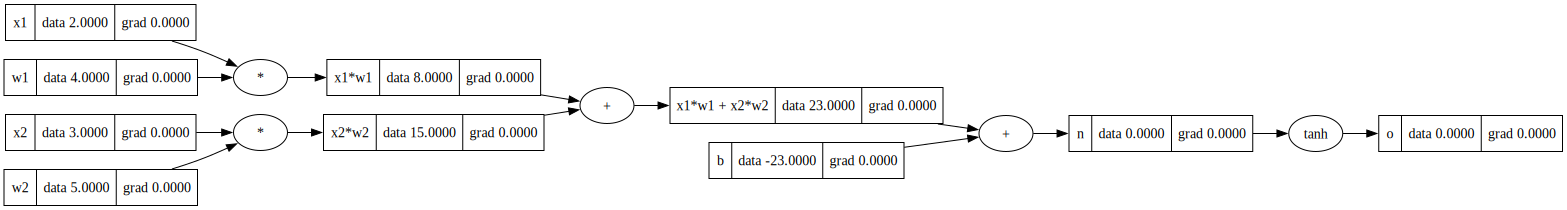

In [145]:
#实验 2：故意顺序跑错
# 清空梯度
for node in topo:
  node.grad = 0.0

# 故意先跑前面的乘法节点
x1w1._backward()
x2w2._backward()

draw_dot(o)


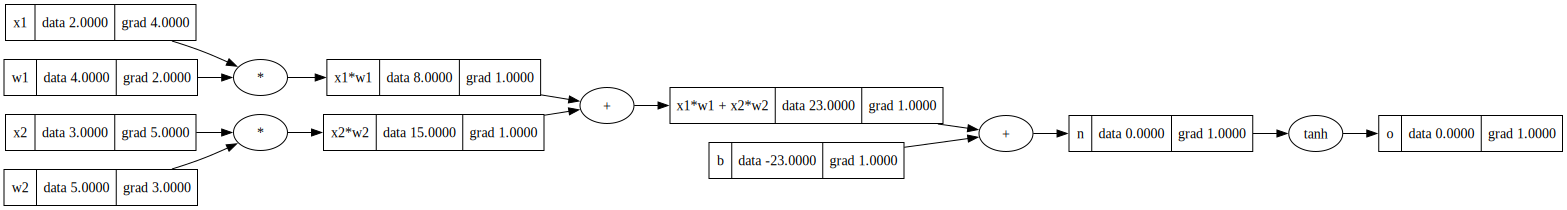

In [146]:
#正确顺序
for node in topo:
  node.grad = 0.0

o.grad = 1.0

o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

draw_dot(o)


In [147]:
#实验 3：用数值扰动验证梯度
h = 0.0001

# 原始输出
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.834231413245123, label='b')

o1 = (x1*w1 + x2*w2 + b).tanh()

# w1 稍微增加 h
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0 + h, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.834231413245123, label='b')

o2 = (x1*w1 + x2*w2 + b).tanh()

(o2.data - o1.data) / h


1.067582197088468

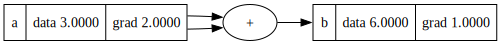

In [54]:
#实验 4：暴露一个小 bug
#我们应该用+=替换= 
a = Value(3.0, label='a')
b = a + a
b.label = 'b'

b.grad = 1.0
b._backward()

a.grad
draw_dot(b)


In [158]:
def make_graph(target_n):
  x1 = Value(2.0, label='x1')
  x2 = Value(3.0, label='x2')

  w1 = Value(4.0, label='w1')
  w2 = Value(5.0, label='w2')

  # 让 n = target_n
  b = Value(target_n - (x1.data*w1.data + x2.data*w2.data), label='b')

  x1w1 = x1 * w1
  x1w1.label = 'x1*w1'

  x2w2 = x2 * w2
  x2w2.label = 'x2*w2'

  x1w1x2w2 = x1w1 + x2w2
  x1w1x2w2.label = 'x1*w1 + x2*w2'

  n = x1w1x2w2 + b
  n.label = 'n'

  o = n.tanh()
  o.label = 'o'

  topo = []
  visited = set()

  def build_topo(v):
    if v not in visited:
      visited.add(v)
      for child in v._prev:
        build_topo(child)
      topo.append(v)

  build_topo(o)

  o.grad = 1.0
  for node in reversed(topo):
    node._backward()

  print('target_n:', target_n)
  print('b:', b.data)
  print('o.data:', o.data)
  print('n.grad:', n.grad)

  return draw_dot(o)


target_n: 0
b: -23.0
o.data: 0.0
n.grad: 1.0


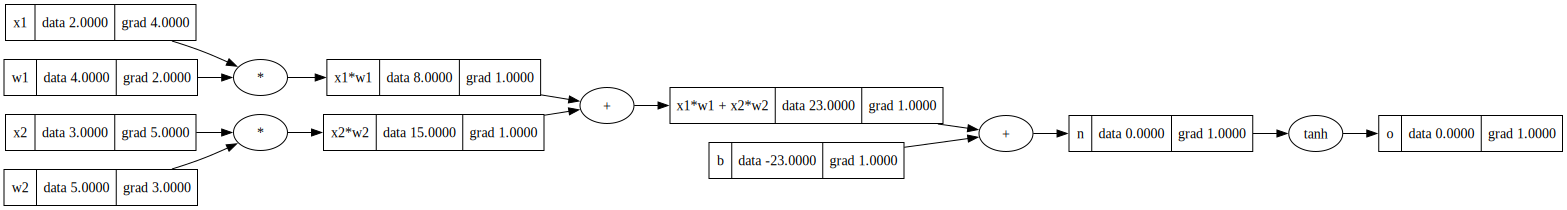

In [159]:
make_graph(0)

target_n: 1
b: -22.0
o.data: 0.7615941559557649
n.grad: 0.41997434161402614


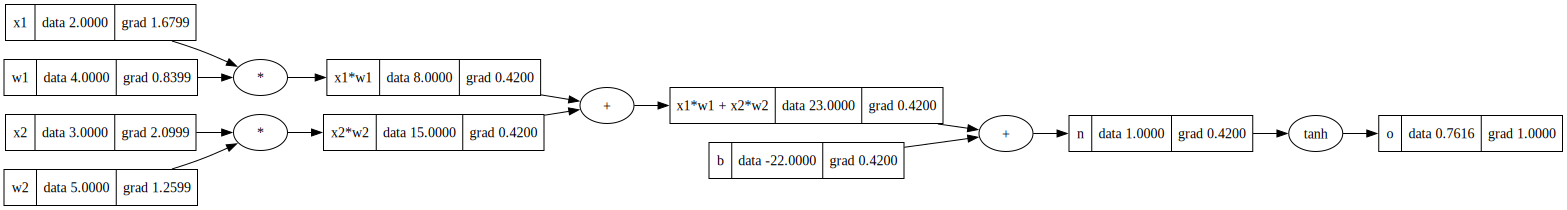

In [160]:
make_graph(1)

target_n: 2
b: -21.0
o.data: 0.9640275800758169
n.grad: 0.07065082485316443


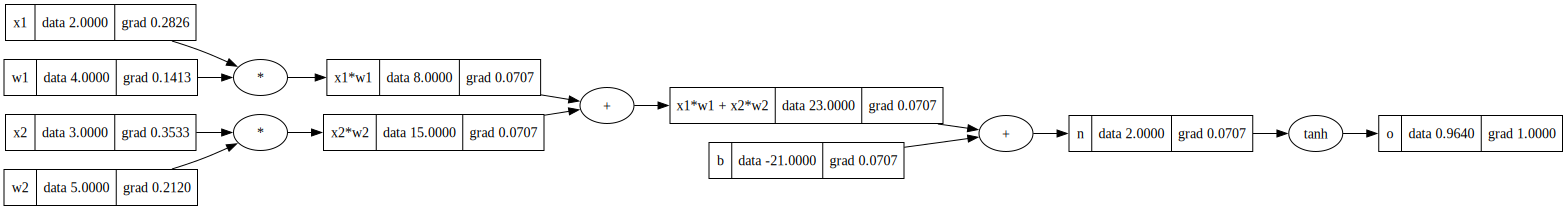

In [161]:
make_graph(2)

target_n: 3
b: -20.0
o.data: 0.9950547536867305
n.grad: 0.009866037165440211


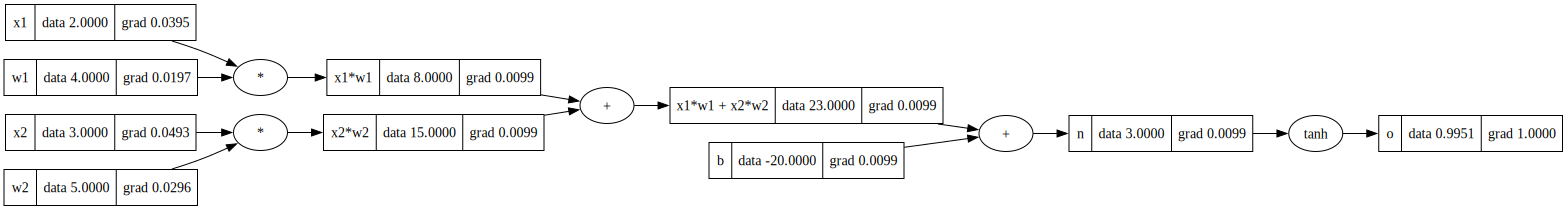

In [162]:
make_graph(3)